# 실험 중간 확인을 허용하되 대가를 미리 지불하는 법

**질문**: 실험 중간에 매일 결과를 확인하면 위양성률이 26%까지 오른다
([01_peeking](01_peeking.ipynb)). 확인을 포기하는 것 말고 다른 방법은 없는가?

**결론**: 확인 시점마다 다른 유의수준을 적용하면 억제할 수 있다.
30회 확인 기준으로 위양성률은 26.2% → 0.7%로 떨어지고,
검정력 손실은 100.0% → 99.0%로 1%p에 그친다.
다만 확인 횟수가 적으면 손실이 커진다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from abtest_lab.sequential import obrien_fleming_alpha, sequential_boundaries
from abtest_lab.simulation import peeking_sim
from abtest_lab.testing import ztest_p

## 1. 알파를 어떻게 나눌 것인가

실험 전체에 배정된 유의수준 0.05를 여러 확인 시점에 나눠 쓴다.
발상은 다중검정의 Bonferroni와 같다. 여러 번 보니까 기준을 나눈다.

문제는 나누는 방식이다. 균등하게 나누면(0.05 / 30) 마지막 시점에도
기준이 0.00167로 남아, 실험이 끝나는 시점에 진짜 효과가 있어도
잡아내기 어려워진다.

O'Brien-Fleming 알파 소비 함수는 불균등하게 나눈다.

In [2]:
rows = []
for day in [1, 5, 10, 15, 20, 25, 30]:
    t = day / 30
    rows.append({
        "일차": day,
        "진행률": round(t, 2),
        "누적 알파": round(obrien_fleming_alpha(t), 5),
    })

pd.DataFrame(rows)

,일차,진행률,누적 알파
0,1,0.03,0.00000
1,5,0.17,0.00000
2,10,0.33,0.00069
3,15,0.50,0.00557
4,20,0.67,0.01637
5,25,0.83,0.03179
6,30,1.00,0.05000


초반에는 사실상 0이다. 1일차에 유의하다고 판정하려면 p값이
0.00000보다 작아야 하므로 조기 종료가 불가능하다.

표본이 적은 초기에는 p값이 크게 출렁이기 때문이다. 그 구간에서
우연히 기준선 아래로 내려간 것을 보고 실험을 멈추는 것이
가장 위험하다.

진행률이 1이 되면 0.05를 전부 쓸 수 있다. **끝까지 실험을 돌렸을 때는
일반 검정과 같은 기준**이 되며, 조기 종료 기회를 열어두는 비용이
최소화되는 지점이다.

In [3]:
b = sequential_boundaries(5)

pd.DataFrame({
    "확인 시점": [f"{i+1}번째" for i in range(len(b))],
    "적용 기준": [round(x, 5) for x in b],
    "균등 분할이라면": [round(0.05 / len(b), 5)] * len(b),
})

,확인 시점,적용 기준,균등 분할이라면
0,1번째,0.00001,0.01
1,2번째,0.00193,0.01
2,3번째,0.00945,0.01
3,4번째,0.01703,0.01
4,5번째,0.02157,0.01


누적 알파를 시점별 차분으로 바꾼 값이다. 이 값을 각 시점의
p값 기준으로 사용한다.

마지막 시점 기준이 첫 번째의 2,000배가 넘는다. 균등 분할과 비교하면
초반에는 훨씬 엄격하고 후반에는 두 배 이상 관대하다.

합계는 0.05로 유지된다.

In [4]:
print("합계:", round(sum(b), 4))

합계: 0.05


## 2. 정말 위양성이 억제되는가

두 그룹의 진짜 전환율을 동일하게 두고 시뮬레이션한다.
실제 차이가 없으므로 유의하다고 판정된 것은 전부 위양성이다.

기존 방식은 매 시점 0.05를 그대로 쓰고, 순차검정은 시점별 경계를 쓴다.
그 한 줄만 다르다.

In [5]:
def sequential_peeking_sim(n_peeks, n_per_day=200, p_base=0.12,
                           n_sims=1000, seed=42):
    rng = np.random.default_rng(seed=seed)
    boundaries = sequential_boundaries(n_peeks)
    results = []

    for _ in range(n_sims):
        any_sig = False
        cum_a = cum_b = cum_n = 0

        for i in range(n_peeks):
            cum_a += rng.binomial(n_per_day, p_base)
            cum_b += rng.binomial(n_per_day, p_base)
            cum_n += n_per_day

            z, p = ztest_p(cum_n, cum_n, cum_a, cum_b)
            if p < boundaries[i]:
                any_sig = True

        results.append(any_sig)

    return np.mean(results)

In [6]:
peeks = [1, 7, 14, 30]

fp_naive = [peeking_sim(k) for k in peeks]
fp_seq = [sequential_peeking_sim(k) for k in peeks]

pd.DataFrame({
    "확인 횟수": peeks,
    "매번 0.05 적용": [f"{x:.1%}" for x in fp_naive],
    "순차 경계 적용": [f"{x:.1%}" for x in fp_seq],
})

,확인 횟수,매번 0.05 적용,순차 경계 적용
0,1,3.9%,3.9%
1,7,16.0%,2.1%
2,14,22.8%,0.9%
3,30,26.2%,0.7%


1회 확인일 때는 두 방식이 같다. 나눌 대상이 없으므로 기준이
0.05 그대로이기 때문이다. 시뮬레이션이 제대로 작동한다는 확인이기도 하다.

30회 확인 시 26.2%에서 0.7%로 떨어진다. 목표였던 5%보다도 낮은데,
이는 구현의 한계 때문이다. 노트북 마지막 절에서 다룬다.

## 3. 대가는 무엇인가

위양성만 보면 순차검정이 무조건 좋아 보인다. 진짜 효과가 있을 때
그것을 잡아내는 능력, 즉 검정력을 함께 봐야 한다.

이번에는 B그룹에 3%p의 실제 차이를 넣는다.

In [7]:
def power_sim(n_peeks, use_sequential, p_a=0.12, p_b=0.15,
              n_per_day=200, n_sims=500, seed=1):
    rng = np.random.default_rng(seed=seed)
    boundaries = sequential_boundaries(n_peeks) if use_sequential else None
    results = []

    for _ in range(n_sims):
        detected = False
        cum_a = cum_b = cum_n = 0

        for i in range(n_peeks):
            cum_a += rng.binomial(n_per_day, p_a)
            cum_b += rng.binomial(n_per_day, p_b)
            cum_n += n_per_day

            z, p = ztest_p(cum_n, cum_n, cum_a, cum_b)
            threshold = boundaries[i] if use_sequential else 0.05
            if p < threshold:
                detected = True

        results.append(detected)

    return np.mean(results)

In [8]:
peeks_pw = [7, 14, 30]

pw_naive = [power_sim(k, False) for k in peeks_pw]
pw_seq = [power_sim(k, True) for k in peeks_pw]

pd.DataFrame({
    "확인 횟수": peeks_pw,
    "매번 0.05 적용": [f"{x:.1%}" for x in pw_naive],
    "순차 경계 적용": [f"{x:.1%}" for x in pw_seq],
})

,확인 횟수,매번 0.05 적용,순차 경계 적용
0,7,76.4%,52.2%
1,14,94.4%,80.6%
2,30,100.0%,99.0%


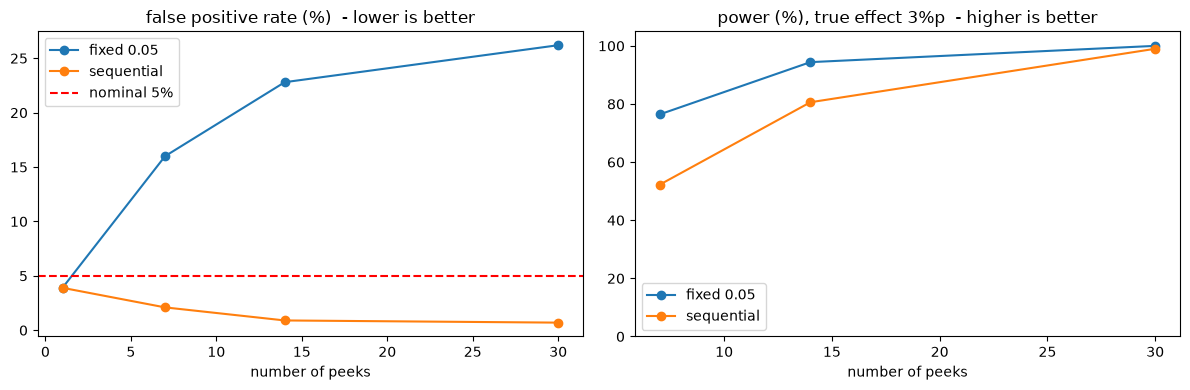

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(peeks, [x * 100 for x in fp_naive], "o-", label="fixed 0.05")
axes[0].plot(peeks, [x * 100 for x in fp_seq], "o-", label="sequential")
axes[0].axhline(5, color="red", linestyle="--", label="nominal 5%")
axes[0].set_title("false positive rate (%)  - lower is better")
axes[0].set_xlabel("number of peeks")
axes[0].legend()

axes[1].plot(peeks_pw, [x * 100 for x in pw_naive], "o-", label="fixed 0.05")
axes[1].plot(peeks_pw, [x * 100 for x in pw_seq], "o-", label="sequential")
axes[1].set_title("power (%), true effect 3%p  - higher is better")
axes[1].set_xlabel("number of peeks")
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. 해석

왼쪽은 낮을수록 좋고 오른쪽은 높을수록 좋다.

**30회 확인에서는 사실상 공짜다.** 검정력은 100.0%에서 99.0%로
1%p만 잃는 반면 위양성률은 26.2%에서 0.7%로 떨어진다.
알파를 마지막 시점에 몰아 쓰도록 설계했기 때문에, 끝까지 가면
일반 검정과 거의 같은 기준이 된다.

**7회 확인에서는 손실이 크다.** 76.4%에서 52.2%로 4분의 1이 날아간다.
확인 횟수가 적으면 각 시점의 알파가 상대적으로 크게 나뉘어
마지막 시점 기준도 그만큼 엄격해진다.

한 가지 덧붙이면, 기존 방식의 30회 검정력 100%는 좋은 숫자가 아니다.
같은 조건에서 위양성률이 26.2%였다. 차이가 없어도 4번 중 1번은
유의하다고 하는 방법으로 달성한 100%다. 검정력만 보고 판단하면 안 된다.

## 5. 언제 쓰나

**끝까지 돌릴 계획이면 쓴다.** 검정력 손실 1%p로 위양성을
26%에서 1% 아래로 낮춘다.

**확인 횟수가 적으면 이득이 적다.** 차라리 확인 시점을 미리 정하고
그때만 판단하는 편이 낫다. 모니터링(버그, SRM, 지표 폭락 감시)과
판단(승패 결정)을 분리하는 원칙은 그대로 유효하다.

## 6. 이 구현의 한계

각 시점의 경계를 누적 알파의 단순 차분으로 구했다.

누적 알파 0.05는 "전체 과정에서 한 번이라도 넘을 확률"인데,
데이터가 누적되므로 인접한 확인 시점의 p값은 서로 독립이 아니다.
따라서 시점별로 단순히 나눠 적용하면 실제 위양성률이 목표보다
보수적으로 나온다. 30회 기준 측정값 0.7%가 그 결과다.

정확한 경계가 필요하면 z통계량 수준에서 계산하는 전용 구현을 쓴다.
이 노트북의 목적은 알파 소비 함수의 원리와 맞바꿈을 확인하는 것이다.